			 Fine 		 Raw 		 Conv
Integral:		 0.96257 	 0.96255 	 1.53541
Max diff:		 				 0.04990


C:\Users\P70095200\AppData\Local\Temp\ipykernel_28352\3902696530.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_fine = np.trapz(I_fine, x_fine)
C:\Users\P70095200\AppData\Local\Temp\ipykernel_28352\3902696530.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_raw = np.trapz(I_raw, x)
C:\Users\P70095200\AppData\Local\Temp\ipykernel_28352\3902696530.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_conv = np.trapz(I_conv, x)


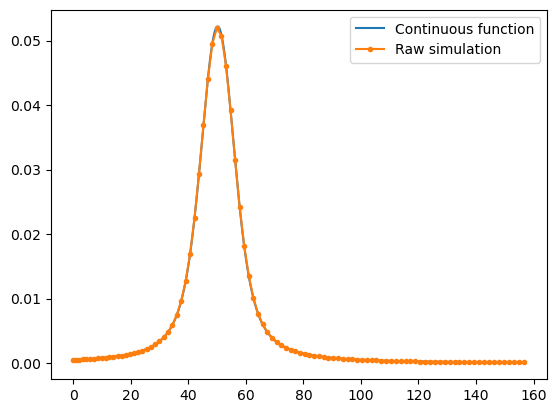

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from ramlab.simulate_spectrum import simulate_convolution, simulate_raw
from scipy.special import voigt_profile

x = np.arange(0, 100, 1)
x_fine = np.linspace(np.min(x), np.max(x), np.size(x)*100)

x_stick = np.array([50.2])
I_stick = np.array([1])

sigma = 4
gamma = 4

I_raw = simulate_raw(x, x_stick, I_stick, sigma=sigma, gamma=gamma, N_bin=10)
I_conv = simulate_convolution(x, x_stick, I_stick, sigma=sigma, gamma=gamma)
I_fine = voigt_profile(x_fine - x_stick, sigma, gamma)

A_fine = np.trapz(I_fine, x_fine)  
A_raw = np.trapz(I_raw, x)
A_conv = np.trapz(I_conv, x)

std_conv_vs_raw = np.std(I_conv - I_raw)

print("\t\t\t Fine \t\t Raw \t\t Conv")
print(f"Integral:\t\t {A_fine:.5f} \t {A_raw:.5f} \t {A_conv:.5f}")
print(f"Std:\t\t\t \t\t\t\t {np.std(I_conv):.5f}")
print(f"Max diff:\t\t \t\t\t\t {np.max(np.abs(I_conv - I_raw)):.5f}")

plt.figure()
plt.plot(x_fine, voigt_profile(x_fine - x_stick, sigma, gamma), label="Continuous function")
plt.plot(x, simulate_raw(x, x_stick, I_stick, sigma=sigma, gamma=gamma, N_bin=50), '.-', label="Raw simulation")
plt.plot(x, simulate_convolution(x, x_stick, I_stick, sigma=sigma, gamma=gamma), '.-', label="Convolution simulation")
plt.xlim(40, 60)
plt.legend()
